In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns # Plots
import matplotlib.pyplot as plt # Plots

# Logistic Regression and Model Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report, accuracy_score

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Random Forest
from sklearn.ensemble import RandomForestClassifier

## Titanic Dataset

* Jede Zeile entspricht einem Passagier
* Wir bekommen einen ersten Überblick über die Datenstruktur
* Die Spalte Cabin enthält fehlende Werte NaN (Not a Number)

### Output Variable
Survived: 0 = Dead, 1 = Survived --> Output Variable

### Input Variablen (mögliche)
Pclass: Ticket class with 1 = 1st class, 2 = 2nd class, 3 = 3rd class

Sex: Gender of male or female

Age: Age in years

SibSp: Number of siblings/spouses aboard the Titanic

Parch: Number of parents/children aboard the Titanic

Ticket: Ticket number

Fare: Passenger fare (Preis)

Cabin: Cabin number

Embarked: Port of Embarkation with C = Cherbourg, Q = Queenstown, S = Southampton

In [2]:
# Datensatz laden
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Unerwünschte Spalten entfernen
# Wir entfernen z.B. 'deck', 'embark_town' (redundant zu 'embarked'), 'alive' (redundant zu 'survived'), 'class' (redundant zu 'pclass')
# Zudem 'who', 'adult_male', 'alone', da sie im Entscheidungsbaum nicht nützlich erscheinen
df_clean = df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'], axis=1)

# Fehlende Werte für 'age', 'embarked' und 'fare' entfernen
df_clean = df_clean.dropna(subset=['age', 'embarked', 'fare'])

In [4]:
# Erzeugen von Dummy Variablen je kategorischer Variablen
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)
df_clean.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# Machine Learning Modelle
## Train-Test-Split

In [5]:
# Input Variablen
X = df_clean.drop('survived', axis=1)
# Output Variable
y = df_clean['survived']

# Test und Trainingssplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression

In [6]:
lr = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)

# Modellanwendung auf Trainings- und Testdaten
y_pred_train_lr = lr.predict(X_train)
y_pred_lr = lr.predict(X_test)

print('Accuracy of Logistic Regression Train: ', accuracy_score(y_pred_train_lr, y_train))
print('Accuracy of Logistic Regression Test: ', accuracy_score(y_pred_lr, y_test))

print(lr.coef_)

Accuracy of Logistic Regression Train:  0.8084358523725835
Accuracy of Logistic Regression Test:  0.7972027972027972
[[-1.29521044e+00 -3.75915182e-02 -3.34913501e-01 -8.23397949e-04
  -5.50456190e-04 -2.57444167e+00 -3.90532496e-01 -2.20679863e-01]]


# Decision Tree

In [7]:


# Modelldefintion ohne Pruning und CV
dtc = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)

# Modellanwendung 
y_pred_train = dtc.predict(X_train)
y_pred = dtc.predict(X_test)

print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))


Accuracy of Decision Tree-Train:  0.9876977152899824
Accuracy of Decision Tree-Test:  0.7202797202797203


[Text(0.4091823340108401, 0.9736842105263158, 'x[5] <= 0.5\ngini = 0.478\nsamples = 569\nvalue = [344, 225]'),
 Text(0.1991869918699187, 0.9210526315789473, 'x[0] <= 2.5\ngini = 0.375\nsamples = 208\nvalue = [52, 156]'),
 Text(0.3041846629403794, 0.9473684210526316, 'True  '),
 Text(0.13279132791327913, 0.868421052631579, 'x[1] <= 56.5\ngini = 0.105\nsamples = 126\nvalue = [7, 119]'),
 Text(0.12195121951219512, 0.8157894736842105, 'x[4] <= 28.856\ngini = 0.091\nsamples = 125\nvalue = [6, 119]'),
 Text(0.0921409214092141, 0.7631578947368421, 'x[4] <= 28.231\ngini = 0.163\nsamples = 56\nvalue = [5, 51]'),
 Text(0.08130081300813008, 0.7105263157894737, 'x[1] <= 27.5\ngini = 0.135\nsamples = 55\nvalue = [4, 51]'),
 Text(0.05420054200542006, 0.6578947368421053, 'x[1] <= 25.5\ngini = 0.245\nsamples = 21\nvalue = [3, 18]'),
 Text(0.032520325203252036, 0.6052631578947368, 'x[4] <= 13.396\ngini = 0.111\nsamples = 17\nvalue = [1, 16]'),
 Text(0.02168021680216802, 0.5526315789473685, 'x[1] <= 20.

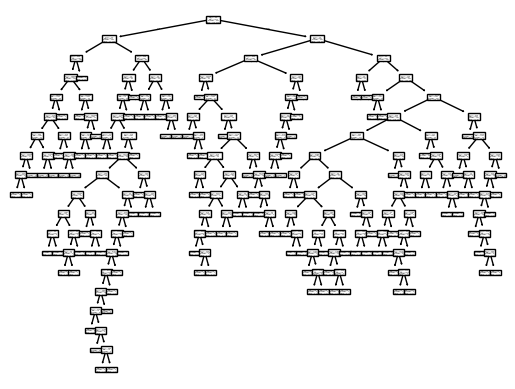

In [8]:
# Plot tree
plot_tree(dtc)

Bestes ccp_alpha durch Cross-Validation: 0.005
Genauigkeit des besten Modells auf dem Testdatensatz: 0.7972


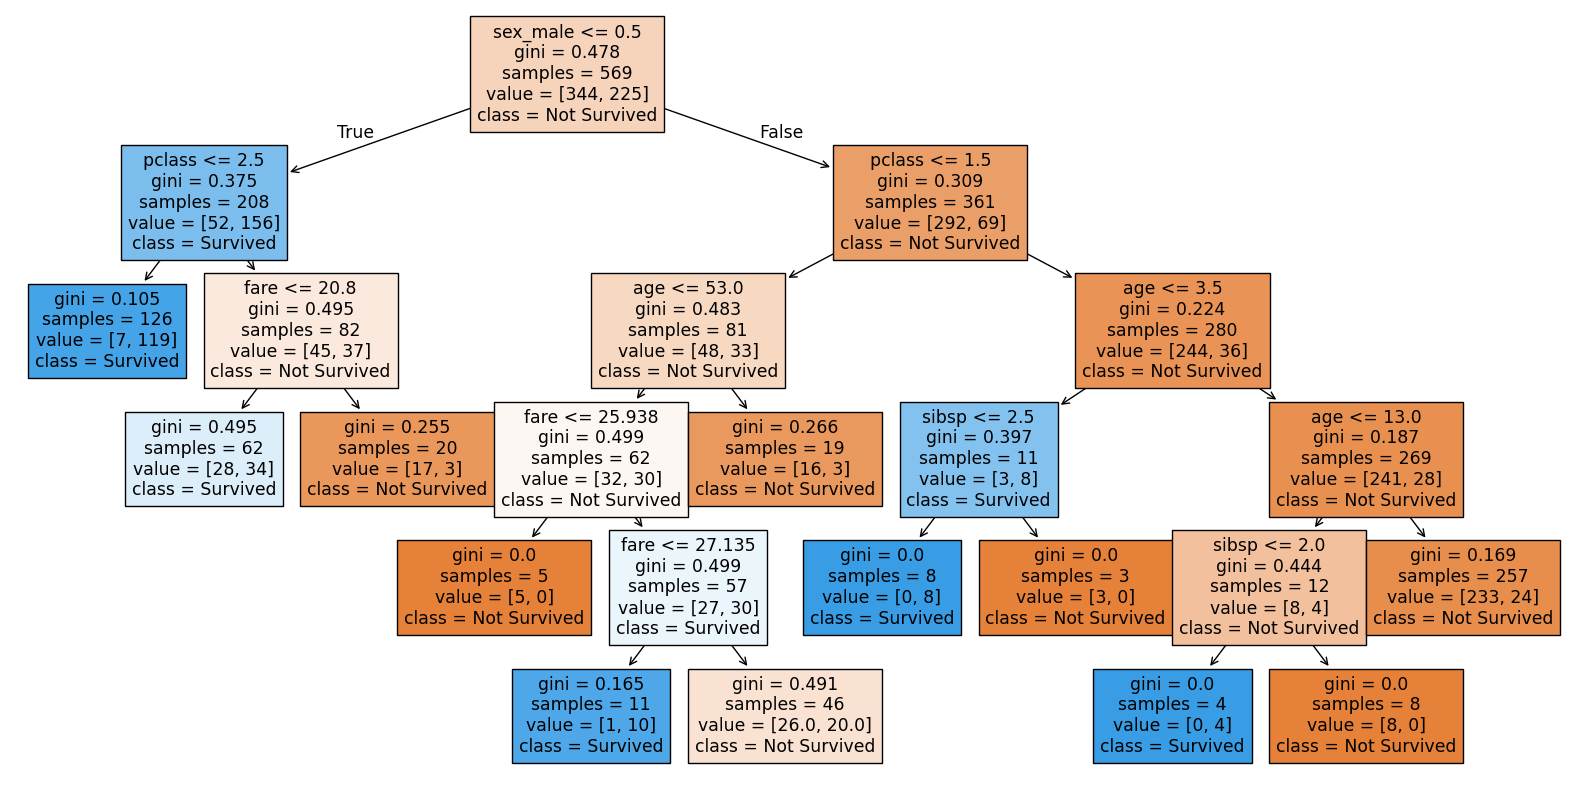

In [9]:
# Ermittlung aller ccp_alpha-Werte durch den Pruning-Pfad
#path = dtc.cost_complexity_pruning_path(X_train, y_train)
#ccp_alphas = path.ccp_alphas

# Verwendung von GridSearchCV zur Bestimmung des besten ccp_alpha-Werts
param_grid = {'ccp_alpha': [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05]}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Das beste ccp_alpha ermitteln
best_ccp_alpha = grid_search.best_params_['ccp_alpha']
print(f"Bestes ccp_alpha durch Cross-Validation: {best_ccp_alpha}")

# Modell mit dem besten ccp_alpha trainieren
best_dtc = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
best_dtc.fit(X_train, y_train)

# Vorhersagen und Genauigkeit auf den Testdaten
y_pred = best_dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit des besten Modells auf dem Testdatensatz: {accuracy:.4f}")

# Entscheidungsbaum des besten Modells visualisieren
plt.figure(figsize=(20, 10))
plot_tree(best_dtc, filled=True, feature_names=X.columns, class_names=["Not Survived", "Survived"])
plt.show()

# Random Forest

In [10]:
rf = RandomForestClassifier(n_estimators=1000, max_depth=5, min_samples_split=2, min_samples_leaf=5, random_state=0)
rf.fit(X_train, y_train)

# Modellanwendung 
y_pred_train_rf = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

print('Accuracy of Random Forest-Train: ', accuracy_score(y_pred_train_rf, y_train))
print('Accuracy of Random Forest-Test: ', accuracy_score(y_pred_rf, y_test))


Accuracy of Random Forest-Train:  0.8576449912126538
Accuracy of Random Forest-Test:  0.8041958041958042


In [11]:
# Grid Search für Hyperparameter-Tuning
param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
GridSearch = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=0)
GridSearch.fit(X_train, y_train)
print(GridSearch.best_params_)

rf = RandomForestClassifier(max_depth=GridSearch.best_params_['max_depth'], min_samples_leaf=GridSearch.best_params_['min_samples_leaf'], 
    min_samples_split=GridSearch.best_params_['min_samples_split'], n_estimators=GridSearch.best_params_['n_estimators'], random_state=0)
rf.fit(X_train, y_train)

# Modellanwendung 
y_pred_train_rf = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

print('Accuracy of Random Forest-Train: ', accuracy_score(y_pred_train_rf, y_train))
print('Accuracy of Random Forest-Test: ', accuracy_score(y_pred_rf, y_test))

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy of Random Forest-Train:  0.9086115992970123
Accuracy of Random Forest-Test:  0.7902097902097902


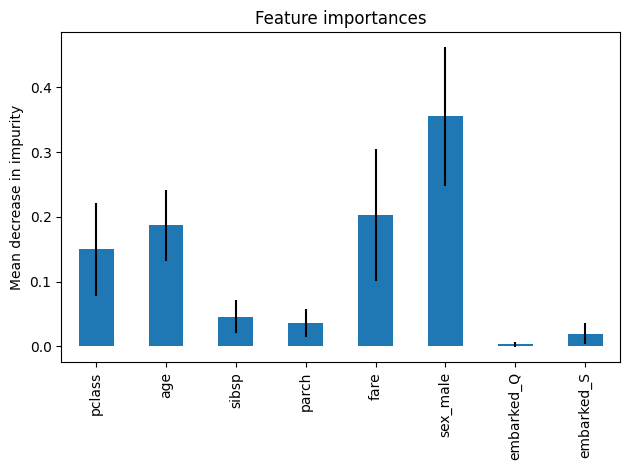

In [14]:
feature_names = X_train.columns

importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()